# CT-ICH

* Contents

1. Patient Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> 1.4 Patient
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    <br> 2.3 Windowing
    3. Slice level Class
    4. Visualization
    
2. Dataset Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    3. Class
    <br> 3.1 Number of Bleed
    <br> 3.2 Type of Bleed
    <br> 3.3 Volume of Bleed
    4. Visualization

3. nnUNet Dataset 구성
<br> class imbalance 고려
<br> filtering 이후

----

In [1]:
import os
from pathlib import Path
from collections import Counter

from scipy import ndimage
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## 1. Patient Unit Analysis

### 1. Basic Info

#### 1. Path

In [2]:
DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data")
DATASET_ROOT = DATA_ROOT / "ct-ich" / "1.3.1"

CT_ROOT = DATASET_ROOT / "ct_scans"
MASK_ROOT = DATASET_ROOT / "masks"
DEMOGRAPHICS_CSV = DATASET_ROOT / "Patient_demographics.csv"
SLICE_LABEL_CSV = DATASET_ROOT / "hemorrhage_diagnosis_raw_ct.csv"

In [3]:
# CT-ICH는 voxel 값이 아니라 CSV 컬럼으로 subtype이 구분됨 (마스크 자체는 binary: 0/255)
class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (0, 255, 255),
}

class_names = {
    1: 'EDH', 
    2: 'IPH', 
    3: 'IVH', 
    4: 'SAH', 
    5: 'SDH'
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

csv_to_short = {
    'Intraventricular': 'IVH',
    'Intraparenchymal': 'IPH',
    'Subarachnoid': 'SAH',
    'Epidural': 'EDH',
    'Subdural': 'SDH',
}

csv_class_columns = ['Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural']

In [4]:
slice_df = pd.read_csv(SLICE_LABEL_CSV, encoding='utf-8-sig')

ct_paths = sorted(CT_ROOT.glob("*.nii"))
mask_paths = sorted(MASK_ROOT.glob("*.nii"))
ct_map = {int(p.stem): p for p in ct_paths}
mask_map = {int(p.stem): p for p in mask_paths}
common_patients = sorted(set(ct_map) & set(mask_map))

print("전체 CT 개수:", len(ct_map))
print("전체 마스크 개수:", len(mask_map))
print("Matched Pair:", len(common_patients))
print("CT Only:", sorted(set(ct_map) - set(mask_map)))
print("Mask Only:", sorted(set(mask_map) - set(ct_map)))

전체 CT 개수: 75
전체 마스크 개수: 75
Matched Pair: 75
CT Only: []
Mask Only: []


In [5]:
# .nii 확장자 파일/ import nibabel as nib로 확인해야 함 
patient_key = common_patients[0]
print("선택 환자:", patient_key)

선택 환자: 49


In [6]:
img_nib = nib.load(str(ct_map[patient_key]))
mask_nib = nib.load(str(mask_map[patient_key]))
img_arr = img_nib.get_fdata()
mask_arr = mask_nib.get_fdata()

In [7]:
print(img_nib)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (512, 512, 39)
affine:
[[-4.12109375e-01 -0.00000000e+00  0.00000000e+00  1.05293945e+02]
 [-0.00000000e+00  4.12109375e-01  0.00000000e+00  2.37060547e+01]
 [ 0.00000000e+00 -0.00000000e+00  5.00000000e+00 -6.90500000e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 48
dim             : [  3 512 512  39   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.          0.41210938  0.41210938  5.          0.          0.
  0.          0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units 

In [8]:
print("이미지 shape:", img_arr.shape, "| dtype:", img_nib.get_data_dtype())
print("마스크 shape:", mask_arr.shape, "| dtype:", mask_nib.get_data_dtype())
print("spacing (zooms):", img_nib.header.get_zooms())
print("affine:\n", img_nib.affine)

orient_code = nib.aff2axcodes(img_nib.affine)
print("orientation:", orient_code)

patient_slices = slice_df[slice_df['PatientNumber'] == patient_key].sort_values('SliceNumber')

print("\nCSV 슬라이스 라벨:")
display(patient_slices)

이미지 shape: (512, 512, 39) | dtype: int16
마스크 shape: (512, 512, 39) | dtype: int16
spacing (zooms): (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))
affine:
 [[-4.12109375e-01 -0.00000000e+00  0.00000000e+00  1.05293945e+02]
 [-0.00000000e+00  4.12109375e-01  0.00000000e+00  2.37060547e+01]
 [ 0.00000000e+00 -0.00000000e+00  5.00000000e+00 -6.90500000e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
orientation: ('L', 'A', 'S')

CSV 슬라이스 라벨:


,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
0,49,1,0,0,0,0,0,1,0
1,49,2,0,0,0,0,0,1,0
2,49,3,0,0,0,0,0,1,0
3,49,4,0,0,0,0,0,1,0
4,49,5,0,0,0,0,0,1,0
5,49,6,0,0,0,0,0,1,0
6,49,7,0,0,0,0,0,1,0
7,49,8,0,0,0,0,0,1,0
8,49,9,0,0,0,0,0,1,0
9,49,10,0,0,0,0,0,1,0


### 2. 3D CT

#### 2.1 Min/Max

In [9]:
flat = img_arr.astype(np.float32).ravel()
percentiles = np.percentile(flat, [0, 0.5, 1, 5, 50, 95, 99, 99.5, 100])
print("min/max:", flat.min(), flat.max())
print("percentiles:", percentiles)

min/max: -1024.0 2914.0
percentiles: [-1024. -1000.  -999.  -998.  -948.   467.  1208.  1397.  2914.]


#### 2.2 HU

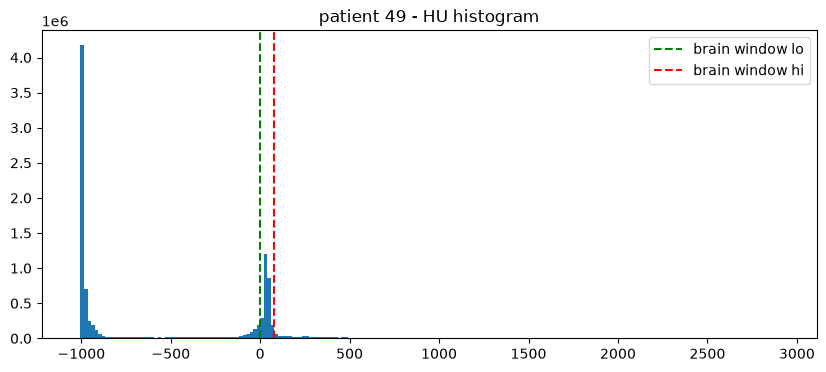

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(flat, bins=200)
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.legend()
plt.title(f'patient {patient_key} - HU histogram')
plt.show()

#### 2.3 Windowing

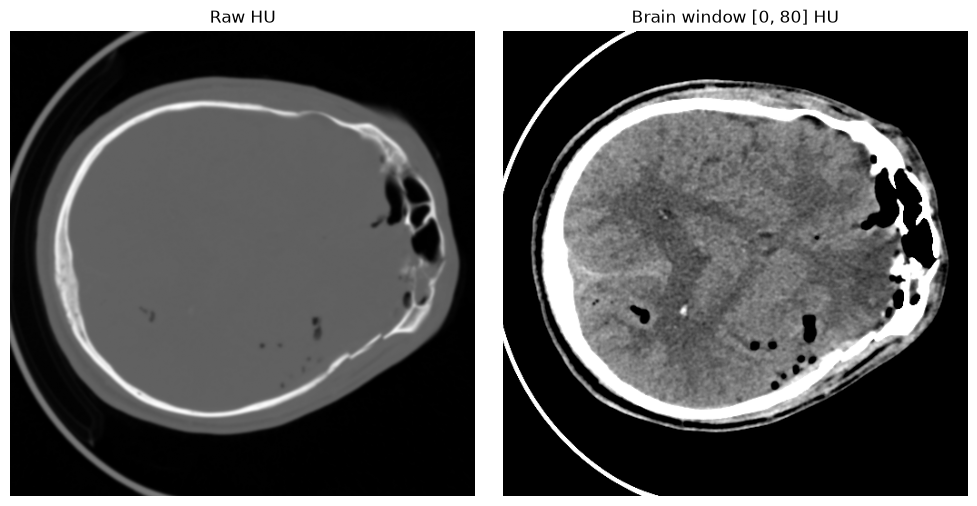

In [11]:
def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

num_slices = img_arr.shape[2]
mid = num_slices // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr[:, :, mid], cmap='gray'); axes[0].set_title('Raw HU'); axes[0].axis('off')
axes[1].imshow(apply_window(img_arr[:, :, mid]), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Brain window [0, 80] HU'); axes[1].axis('off')
plt.tight_layout()
plt.show()

### 3. Slice level Class

In [12]:
rows = []
for _, row in patient_slices.iterrows():
    z = int(row['SliceNumber']) - 1
    classes_present = [csv_to_short[c] for c in csv_class_columns if row[c] == 1]
    fg_voxels = int((mask_arr[:, :, z] > 0).sum()) if 0 <= z < mask_arr.shape[2] else np.nan
    rows.append({
        'slice': z,
        'n_classes': len(classes_present),
        'classes': ', '.join(classes_present),
        'fg_voxels(mask)': fg_voxels,
    })

df_slices = pd.DataFrame(rows)
display(df_slices[df_slices['n_classes'] > 0])

,slice,n_classes,classes,fg_voxels(mask)
13,13,1,EDH,436
14,14,1,EDH,1156
15,15,1,EDH,1080
16,16,1,EDH,1130
19,19,1,EDH,263
20,20,2,"IPH, EDH",890
21,21,1,EDH,731
22,22,1,EDH,383
26,26,1,IPH,109


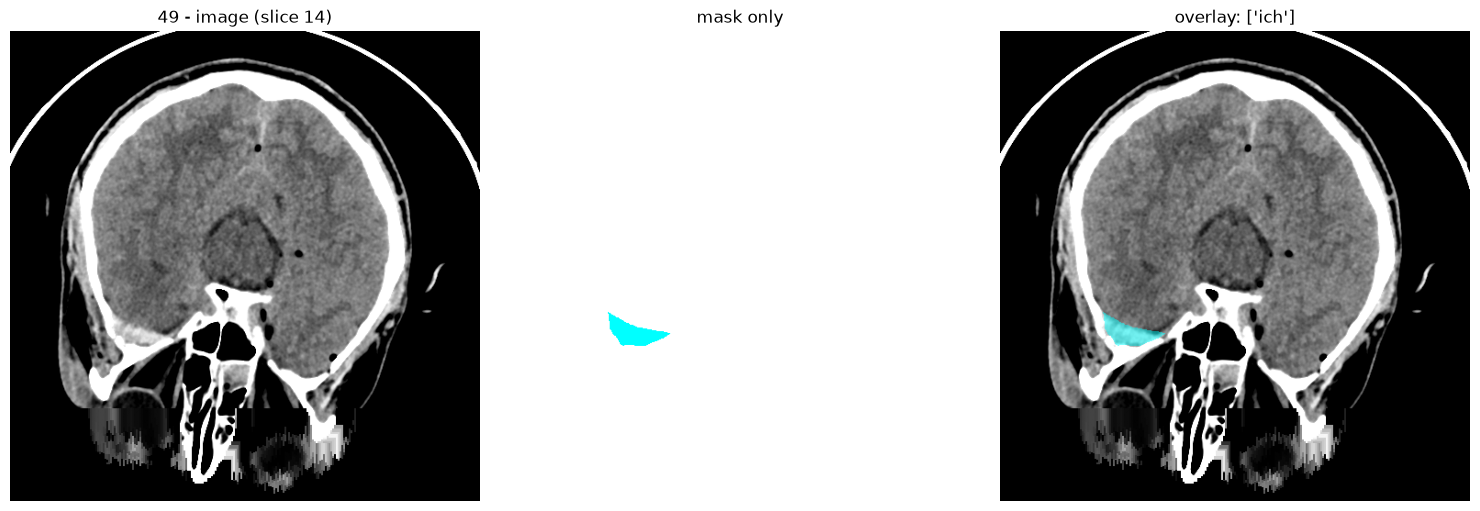

In [13]:
best_z = int(df_slices['fg_voxels(mask)'].idxmax())
windowed_slice = apply_window(img_arr[:, :, best_z].T)   # [best_z] 아님
mask_slice = mask_arr[:, :, best_z].T                     # [best_z] 아님
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

n_classes_1cls = max(class_colors_1cls.keys()) + 1   # 2 (0, 1)
colors_rgb_1cls = np.zeros((n_classes_1cls, 3))
for cls, rgb in class_colors_1cls.items():
    colors_rgb_1cls[cls] = np.array(rgb) / 255
custom_cmap_1cls = ListedColormap(colors_rgb_1cls)

mask_binary = (mask_slice > 0).astype(int)   # 0/1로 정규화 (원래 255 값이면 정규화가 꼬일 수 있음)
mask_only_display = np.ma.masked_where(mask_binary == 0, mask_binary)
mask_overlay = np.ma.masked_where(mask_binary == 0, mask_binary)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'{patient_key} - image (slice {best_z})')
axes[0].axis('off')

axes[1].set_facecolor('white')
axes[1].imshow(mask_only_display, cmap=custom_cmap_1cls, vmin=0, vmax=1)
axes[1].set_title('mask only')
axes[1].axis('off')

axes[2].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(mask_overlay, cmap=custom_cmap_1cls, alpha=0.5, vmin=0, vmax=1)
present = [class_names_1cls[c] for c in np.unique(mask_binary) if c != 0]
axes[2].set_title(f'overlay: {present}')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### 4. Visualization

In [14]:
from ctviewer import CTViewer
CTViewer(img_arr)

interactive(children=(RadioButtons(description='Slice plane selection:', index=2, options=('y-z', 'z-x', 'x-y'…

## 2. Dataset Unit Analysis

### 1. Basic Info

#### 1.3 Dataset 

In [15]:
meta_rows = []
for pnum in common_patients:
    img = nib.load(str(ct_map[pnum]))
    meta_rows.append({
        'patient': pnum,
        'shape': img.shape,
        'dtype': img.get_data_dtype(),
        'spacing': img.header.get_zooms(),
        'affine_diag': tuple(np.diag(img.affine)[:3]),
        'orientation': nib.aff2axcodes(img.affine),
    })
df_meta = pd.DataFrame(meta_rows)
display(df_meta.head())

print("\n서로 다른 shape 종류 수:", df_meta['shape'].nunique())
print("서로 다른 spacing 종류 수:", df_meta['spacing'].nunique())
print("서로 다른 dtype 종류:", df_meta['dtype'].unique())
print("서로 다른 orientation 종류:", df_meta['orientation'].unique())

,patient,shape,dtype,spacing,affine_diag,orientation
0,49,"(512, 512, 39)",int16,"(0.41210938, 0.41210938, 5.0)","(-0.412109375, 0.412109375, 5.0)","(L, A, S)"
1,50,"(512, 512, 32)",int16,"(0.3515625, 0.3515625, 5.0)","(-0.3515625, 0.3515625, 5.0)","(L, A, S)"
2,51,"(512, 512, 46)",int16,"(0.41210938, 0.41210938, 5.0)","(-0.412109375, 0.412109375, 5.0)","(L, A, S)"
3,52,"(512, 512, 35)",int16,"(0.390625, 0.390625, 5.0)","(-0.390625, 0.390625, 5.0)","(L, A, S)"
4,53,"(512, 512, 35)",int16,"(0.47265625, 0.47265625, 5.0)","(-0.47265625, 0.47265625, 5.0)","(L, A, S)"



서로 다른 shape 종류 수: 19
서로 다른 spacing 종류 수: 35
서로 다른 dtype 종류: [dtype('<i2')]
서로 다른 orientation 종류: [('L', 'A', 'S')]


### 2. 3D CT

#### 2.1 Min/Max

In [16]:
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

hu_rows = []
for pnum in common_patients:
    arr = nib.load(str(ct_map[pnum])).get_fdata().astype(np.float32)
    flat = arr.ravel()
    p = np.percentile(flat, [0.5, 1, 5, 50, 95, 99, 99.5])
    hu_rows.append({
        'patient': pnum, 'min': flat.min(), 'max': flat.max(),
        'p0.5': p[0], 'p1': p[1], 'p5': p[2], 'p50': p[3], 'p95': p[4], 'p99': p[5], 'p99.5': p[6],
    })
df_hu = pd.DataFrame(hu_rows)
display(df_hu.describe())

,patient,min,max,p0.5,p1,p5,p50,p95,p99,p99.5
count,75.00,75.00,75.00,75.00,75.00,75.00,75.00,75.00,75.00,75.00
mean,92.07,-1022.44,2702.00,-1001.44,-1000.60,-999.08,-944.08,442.41,1077.80,1223.16
std,23.29,2.47,390.49,1.44,1.36,1.24,47.80,204.03,251.83,243.70
min,49.00,-1024.00,1713.00,-1005.00,-1003.00,-1001.00,-992.00,62.00,396.00,551.00
25%,74.50,-1024.00,2412.00,-1002.00,-1002.00,-1000.50,-971.50,283.00,932.50,1067.00
50%,93.00,-1024.00,2848.00,-1001.00,-1000.00,-999.00,-962.00,419.00,1114.00,1253.00
75%,111.50,-1021.00,3040.00,-1000.00,-999.00,-998.00,-931.50,572.00,1276.50,1415.50
max,130.00,-1014.00,3071.00,-999.00,-999.00,-998.00,-739.00,916.00,1559.00,1646.00


#### 2.2 HU

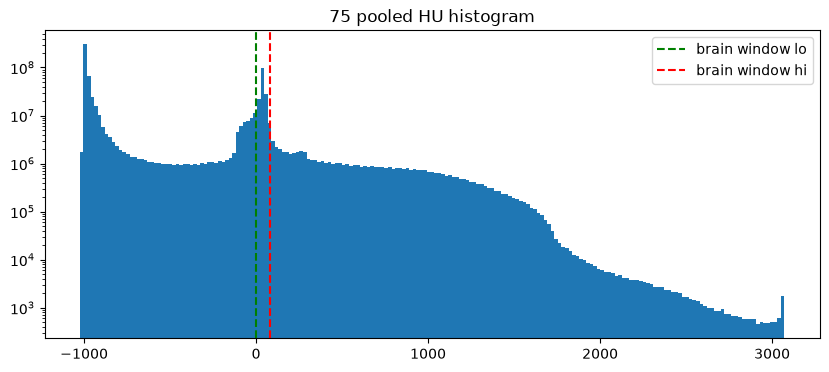

In [17]:
bin_edges = np.linspace(-1024, 3072, 200)
hist_total = np.zeros(len(bin_edges) - 1)
for pnum in common_patients:
    arr = nib.load(str(ct_map[pnum])).get_fdata().astype(np.float32)
    counts, _ = np.histogram(arr.ravel(), bins=bin_edges)
    hist_total += counts

plt.figure(figsize=(10, 4))
plt.bar(bin_edges[:-1], hist_total, width=np.diff(bin_edges), align='edge')
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.yscale('log')
plt.legend()
plt.title(f'{len(common_patients)} pooled HU histogram')
plt.show()

### 3. Class

#### 3.1 Number of Bleed

In [18]:
slice_df_valid = slice_df[slice_df['PatientNumber'].isin(common_patients)].copy()
slice_df_valid['n_classes'] = slice_df_valid[csv_class_columns].sum(axis=1)

slice_bleed_counter = Counter(slice_df_valid['n_classes'])
scan_n_classes = slice_df_valid.groupby('PatientNumber')[csv_class_columns].max().sum(axis=1)
scan_bleed_counter = Counter((scan_n_classes > 0).astype(int) * scan_n_classes.astype(int))
# 위 줄 대신 명확하게:
scan_n_classes = (slice_df_valid.groupby('PatientNumber')[csv_class_columns].max() > 0).sum(axis=1)
scan_bleed_counter = Counter(scan_n_classes)

df_num_bleeds = pd.DataFrame({
    'n_classes co-occurring': range(6),
    'slice count': [slice_bleed_counter.get(n, 0) for n in range(6)],
    'scan count': [scan_bleed_counter.get(n, 0) for n in range(6)],
})
display(df_num_bleeds)

,n_classes co-occurring,slice count,scan count
0,0,2496,39
1,1,293,23
2,2,24,10
3,3,1,2
4,4,0,1
5,5,0,0


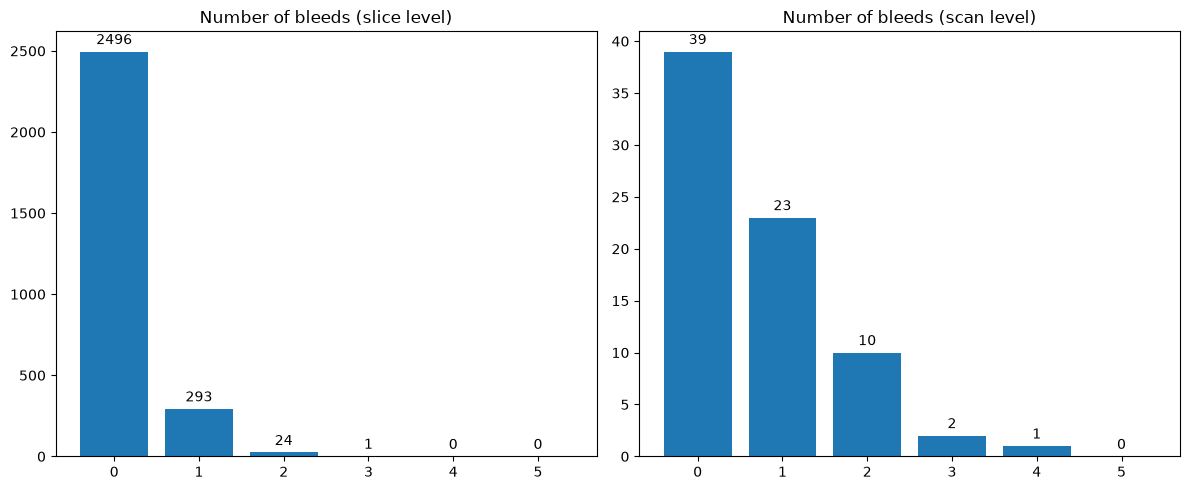

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = list(range(6))
bars0 = axes[0].bar(x, df_num_bleeds['slice count'])
axes[0].set_title('Number of bleeds (slice level)'); axes[0].bar_label(bars0, padding=3)
bars1 = axes[1].bar(x, df_num_bleeds['scan count'])
axes[1].set_title('Number of bleeds (scan level)'); axes[1].bar_label(bars1, padding=3)
plt.tight_layout()
plt.show()

#### 3.2 Type of Bleed

,type,slice count,scan count
0,EDH,173,21
1,IPH,73,16
2,IVH,24,5
3,SAH,18,7
4,SDH,56,4


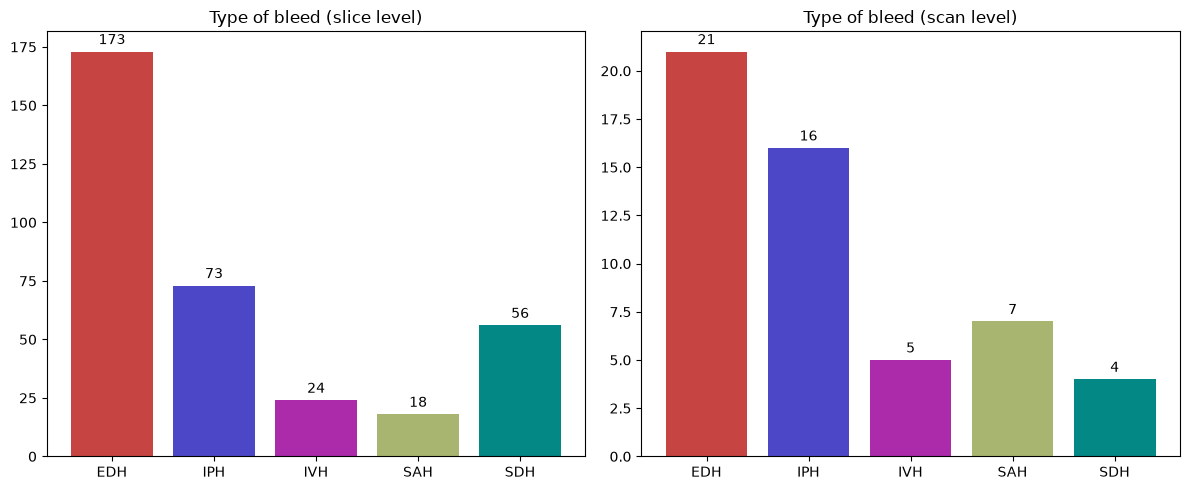

In [ ]:
csv_to_short = {
    'Intraventricular': 'IVH',
    'Intraparenchymal': 'IPH',
    'Subarachnoid': 'SAH',
    'Epidural': 'EDH',
    'Subdural': 'SDH',
}
class_colors_short = {
    'EDH': (198, 68, 66),
    'IPH': (76, 71, 199),
    'IVH': (171, 43, 171),
    'SAH': (168, 181, 112),
    'SDH': (4, 136, 133),
}

desired_order = ['EDH', 'IPH', 'IVH', 'SAH', 'SDH']

slice_type_counts = slice_df_valid[csv_class_columns].sum()
scan_type_presence = (slice_df_valid.groupby('PatientNumber')[csv_class_columns].max() > 0).sum()

df_type_bleed = pd.DataFrame({
    'type': [csv_to_short[c] for c in csv_class_columns],
    'slice count': slice_type_counts.values,
    'scan count': scan_type_presence.values,
})
df_type_bleed = df_type_bleed.set_index('type').loc[desired_order].reset_index()  # 순서 고정
display(df_type_bleed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = [np.array(class_colors_short[t]) / 255 for t in df_type_bleed['type']]
bars0 = axes[0].bar(df_type_bleed['type'], df_type_bleed['slice count'], color=colors)
axes[0].set_title('Type of bleed (slice level)'); axes[0].bar_label(bars0, padding=3)
bars1 = axes[1].bar(df_type_bleed['type'], df_type_bleed['scan count'], color=colors)
axes[1].set_title('Type of bleed (scan level)'); axes[1].bar_label(bars1, padding=3)
plt.tight_layout()
plt.show()

#### 3.3 Volume of Bleed

In [21]:
# 주의: mask가 binary라 subtype별 volume은 원칙적으로 계산 불가.
# "한 슬라이스에 subtype이 정확히 1개"인 경우에만 근사적으로 그 subtype의 volume으로 카운트.

lesion_sizes_mm3 = {c: [] for c in csv_class_columns}

for pnum in common_patients:
    img = nib.load(str(ct_map[pnum]))
    mask = nib.load(str(mask_map[pnum])).get_fdata()
    spacing = img.header.get_zooms()
    voxel_volume_mm3 = float(np.prod(spacing))

    p_slices = slice_df_valid[slice_df_valid['PatientNumber'] == pnum].sort_values('SliceNumber').reset_index(drop=True)
    for i, row in p_slices.iterrows():
        active = [c for c in csv_class_columns if row[c] == 1]
        if len(active) != 1 or i >= mask.shape[2]:
            continue
        fg = int((mask[:, :, i] > 0).sum())
        if fg > 0:
            lesion_sizes_mm3[active[0]].append(fg * voxel_volume_mm3)

rows = []
for c in csv_class_columns:
    sizes = np.array(lesion_sizes_mm3[c])
    rows.append({
        'type': csv_to_short[c],
        'n_single_label_slices': len(sizes),
        'mean_mm3': sizes.mean() if len(sizes) else np.nan,
        'median_mm3': np.median(sizes) if len(sizes) else np.nan,
        'max_mm3': sizes.max() if len(sizes) else np.nan,
    })
df_volume = pd.DataFrame(rows)
display(df_volume)

,type,n_single_label_slices,mean_mm3,median_mm3,max_mm3
0,IVH,13,643.54,595.46,1160.73
1,IPH,52,1085.44,514.03,7683.82
2,SAH,9,1013.35,1096.85,1493.67
3,EDH,167,1377.06,917.10,7614.14
4,SDH,52,3237.23,2428.63,9610.22


#### 3.4 Class Weight

In [22]:
total_scan_labeled = scan_type_presence.sum()
class_weights = {
    csv_to_short[c]: total_scan_labeled / (scan_type_presence[c] * 5)
    for c in csv_class_columns
}
print("scan 등장 빈도 역가중치 기반 class weight:", class_weights)

scan 등장 빈도 역가중치 기반 class weight: {'IVH': np.float64(2.12), 'IPH': np.float64(0.6625), 'SAH': np.float64(1.5142857142857142), 'EDH': np.float64(0.5047619047619047), 'SDH': np.float64(2.65)}


### 4. Visualization

In [23]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# Build custom colormap (binary: 0=background, 1=ich)
n_classes_1cls = max(class_colors_1cls.keys()) + 1
colors_rgb_1cls = np.zeros((n_classes_1cls, 3))
for cls, rgb in class_colors_1cls.items():
    colors_rgb_1cls[cls] = np.array(rgb) / 255.0
custom_cmap_1cls = ListedColormap(colors_rgb_1cls)

fig, axes = plt.subplots(len(selected), 3, figsize=(16, 4.8 * len(selected)))
if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in enumerate(selected):
    pnum, z = row['patient'], int(row['best_z'])

    img = nib.load(str(ct_map[pnum])).get_fdata()
    mask = nib.load(str(mask_map[pnum])).get_fdata()
    image_slice = apply_window(img[:, :, z].T)
    mask_slice = (mask[:, :, z] > 0).astype(int).T
    mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
    mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)

    # 이 슬라이스의 실제 subtype (CSV 기반, 텍스트 표시용)
    row_csv = slice_df_valid[
        (slice_df_valid['PatientNumber'] == pnum) & (slice_df_valid['SliceNumber'] == z + 1)
    ]
    active_types = [csv_to_short[c] for c in csv_class_columns if row_csv[c].max() == 1] if not row_csv.empty else []

    axes[i, 0].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(f"patient {pnum}")
    axes[i, 0].axis("off")
    axes[i, 0].text(
        0.02, 0.98,
        f"Patient: {pnum}\nz: {z}\ntypes(CSV): {', '.join(active_types) if active_types else '-'}",
        transform=axes[i, 0].transAxes,
        va="top", ha="left", fontsize=10, color="white",
        bbox=dict(facecolor="black", alpha=0.55, edgecolor="none", pad=4),
    )

    axes[i, 1].set_facecolor("black")
    axes[i, 1].imshow(mask_only_display, cmap=custom_cmap_1cls, vmin=0, vmax=1)
    axes[i, 1].set_title("mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 2].imshow(mask_overlay, cmap=custom_cmap_1cls, alpha=0.5, vmin=0, vmax=1)
    axes[i, 2].set_title("overlay")
    axes[i, 2].axis("off")

legend_handles = [
    Patch(facecolor=np.array(class_colors_1cls[c]) / 255.0, edgecolor="none", label=class_names_1cls[c])
    for c in sorted(class_colors_1cls) if c != 0
]

fig.suptitle("Representative slices by scan-level bleed count", y=0.995, fontsize=14)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

NameError: name 'selected' is not defined

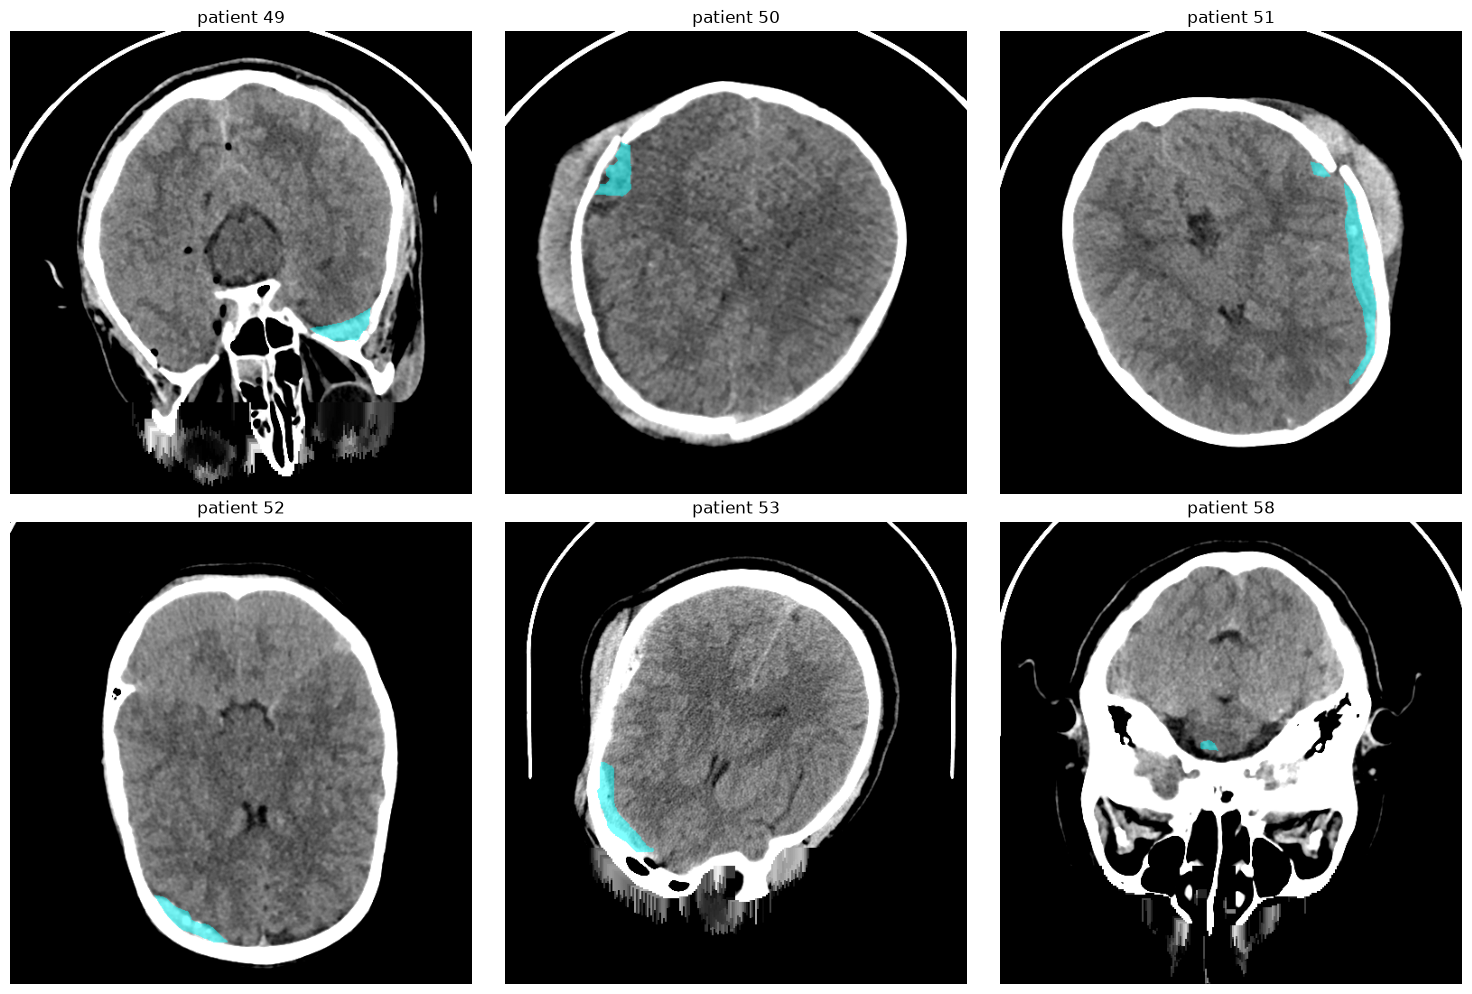

In [24]:
patients_with_lesion = [
    pnum for pnum in common_patients
    if (nib.load(str(mask_map[pnum])).get_fdata() > 0).any()
]
sample_patients = patients_with_lesion[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, pnum in zip(axes.ravel(), sample_patients):
    arr = nib.load(str(ct_map[pnum])).get_fdata()
    marr = nib.load(str(mask_map[pnum])).get_fdata()
    fg_per_slice = marr.sum(axis=(0, 1))
    z = int(fg_per_slice.argmax())

    windowed = np.rot90(apply_window(arr[:, :, z]), k=-1)
    mask_slice = np.rot90(marr[:, :, z], k=-1)
    overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

    ax.imshow(windowed, cmap='gray')
    ax.imshow(overlay, cmap=custom_cmap_1cls, vmin=0, vmax=1, alpha=0.5)
    ax.set_title(f"patient {pnum}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. nnUNet Dataset

In [25]:
import json
import shutil
import random
from pathlib import Path

# 75명(matched pair)만 대상 -> common_patients 사용
patients = sorted(common_patients)
n_patients = len(patients)

rng = random.Random(42)
shuffled = patients[:]
rng.shuffle(shuffled)

n_val = round(n_patients * 0.2)   # 4:1 = 80:20
val_patients = sorted(shuffled[:n_val])
train_patients = sorted(shuffled[n_val:])

print(f"전체 환자: {n_patients}")
print(f"train: {len(train_patients)}, test(val): {len(val_patients)}")

전체 환자: 75
train: 60, test(val): 15


In [ ]:
"""
NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")
DATASET_ID = 5
DATASET_NAME = f"Dataset{DATASET_ID:03d}_CTICH_1cls"

DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / DATASET_NAME
imagesTr = DATASET_DIR / "imagesTr"
labelsTr = DATASET_DIR / "labelsTr"
imagesTs = DATASET_DIR / "imagesTs"
labelsTs = DATASET_DIR / "labelsTs"
for d in (imagesTr, labelsTr, imagesTs, labelsTs):
    d.mkdir(parents=True, exist_ok=True)

for pnum in train_patients:
    cid = f"ctich_{pnum:03d}"
    shutil.copy2(ct_map[pnum], imagesTr / f"{cid}_0000.nii")
    shutil.copy2(mask_map[pnum], labelsTr / f"{cid}.nii")

for pnum in val_patients:
    cid = f"ctich_{pnum:03d}"
    shutil.copy2(ct_map[pnum], imagesTs / f"{cid}_0000.nii")
    shutil.copy2(mask_map[pnum], labelsTs / f"{cid}.nii")

dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0, "ich": 1},
    "numTraining": len(train_patients),
    "file_ending": ".nii",
}
with open(DATASET_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print(f"Train(Tr): {len(train_patients)}, Test(Ts): {len(val_patients)}")
print("dataset.json:", DATASET_DIR / "dataset.json")
"""

Train(Tr): 60, Test(Ts): 15
dataset.json: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset005_CTICH_1cls/dataset.json


In [ ]:
"""
DATASET_CTICH_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset005_CTICH_1cls")

for label_dir in ["labelsTr", "labelsTs"]:
    for label_path in sorted((DATASET_CTICH_DIR / label_dir).glob("*.nii")):
        nii = nib.load(str(label_path))
        arr = (nii.get_fdata() > 0).astype(np.uint8)   # 0/255 -> 0/1
        fixed = nib.Nifti1Image(arr, nii.affine, nii.header)
        nib.save(fixed, str(label_path))

print("라벨 0/1 변환 완료")
"""


라벨 0/1 변환 완료


In [ ]:
"""AttributeError
for label_path in list((DATASET_CTICH_DIR / "labelsTr").glob("*.nii"))[:5]:
    arr = nib.load(str(label_path)).get_fdata()
    print(label_path.name, np.unique(arr))
"""

ctich_108.nii [0.]
ctich_079.nii [0. 1.]
ctich_122.nii [0.]
ctich_090.nii [0. 1.]
ctich_088.nii [0. 1.]


* 처리 전

In [87]:
print(common_patients)
print(len(common_patients))

[49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]
75


In [80]:
print(slice_df_valid.head(1)) # common_patient 기준
print(slice_df.shape)
print(len(slice_df['PatientNumber'].unique()))

   PatientNumber  SliceNumber  Intraventricular  Intraparenchymal  \
0             49            1                 0                 0   

   Subarachnoid  Epidural  Subdural  No_Hemorrhage  Fracture_Yes_No  n_classes  
0             0         0         0              1                0          0  
(2814, 9)
75


In [ ]:
csv_class_columns = ['Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural']
order = ['EDH', 'IPH', 'IVH', 'SAH', 'SDH']

In [ ]:
print(slice_df_valid['Epidural'].head())        # 문자열 하나로 series에 접근 
print(slice_df_valid[csv_class_columns].head()) # list로 data frame에 접근

0    0
1    0
2    0
3    0
4    0
Name: Epidural, dtype: int64
   Intraventricular  Intraparenchymal  Subarachnoid  Epidural  Subdural
0                 0                 0             0         0         0
1                 0                 0             0         0         0
2                 0                 0             0         0         0
3                 0                 0             0         0         0
4                 0                 0             0         0         0


In [ ]:
# 슬라이스 기준
n_slices_before = len(slice_df_valid)
slice_type_counts_before = slice_df_valid[csv_class_columns].sum().rename(index=csv_to_short).loc[order]
slice_n_classes_dist_before = slice_df_valid['n_classes'].value_counts().sort_index()

print("총 슬라이스 개수:", n_slices_before)
print("\n슬라이스 별 병변 개수:")
print(slice_type_counts_before.to_string())
print("\nco-occurrence 별 슬라이스 개수:")
print(slice_n_classes_dist_before.to_string())

총 슬라이스 개수: 2814

슬라이스 별 병변 개수:
EDH    173
IPH     73
IVH     24
SAH     18
SDH     56

co-occurrence 별 슬라이스 개수:
n_classes
0    2496
1     293
2      24
3       1


In [ ]:
# 스캔 기준 
n_scans_before = slice_df_valid['PatientNumber'].nunique()
scan_type_counts_before = (slice_df_valid.groupby('PatientNumber')[csv_class_columns].max() > 0).sum().rename(index=csv_to_short).loc[order]
scan_n_types_before = (slice_df_valid.groupby('PatientNumber')[csv_class_columns].max() > 0).sum(axis=1)
scan_n_types_dist_before = scan_n_types_before.value_counts().sort_index()

print("총 스캔 개수:", n_scans_before)
print("\n병변 타입 별 스캔 개수:")
print(scan_type_counts_before.to_string())
print("\n병변 타입 개수 별 스캔 개수:")
print(scan_n_types_dist_before.to_string())

총 스캔 개수: 75

병변 타입 별 스캔 개수:
EDH    21
IPH    16
IVH     5
SAH     7
SDH     4

병변 타입 개수 별 스캔 개수:
0    39
1    23
2    10
3     2
4     1


* 처리 후

In [ ]:
multi_class_slice_patients = set(
    int(p) for p in slice_df_valid.loc[slice_df_valid['n_classes'] >= 2, 'PatientNumber'].unique()
)

print(len(multi_class_slice_patients))
print(type(multi_class_slice_patients))
print(multi_class_slice_patients)

9
<class 'set'>
{97, 71, 76, 80, 49, 91, 92, 93, 94}


In [ ]:
# 단일 슬라이스 환자 스캔 선별
multi_class_slice_patients = set(
    int(p) for p in slice_df_valid.loc[slice_df_valid['n_classes'] >= 2, 'PatientNumber'].unique()
)
    # comprehension
    # 
selected_patients = sorted(p for p in common_patients if p not in multi_class_slice_patients)

print(f"전체 매칭 환자: {len(common_patients)}")
print(f"슬라이스 co-occurrence로 제외된 환자: {len(multi_class_slice_patients)}: {sorted(multi_class_slice_patients)}")
print(f"선정된 환자 (Test2_CTICH 대상): {len(selected_patients)}")
print(selected_patients)

전체 매칭 환자: 75
슬라이스 co-occurrence로 제외된 환자: 9: [49, 71, 76, 80, 91, 92, 93, 94, 97]
선정된 환자 (Test2_CTICH 대상): 66
[50, 51, 52, 53, 54, 55, 56, 57, 58, 66, 67, 68, 69, 70, 72, 73, 74, 75, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 95, 96, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]


In [ ]:
# 선정 환자별 병변 타입 확인 
selected_slice_df = slice_df_valid[slice_df_valid['PatientNumber'].isin(selected_patients)]

patient_types = {}
for pnum in selected_patients:
    p_rows = selected_slice_df[selected_slice_df['PatientNumber'] == pnum]
    present = [csv_to_short[c] for c in csv_class_columns if p_rows[c].max() == 1]
    patient_types[pnum] = present

df_selected = pd.DataFrame({
    'patient': selected_patients,
    'lesion_types': [', '.join(patient_types[p]) if patient_types[p] else '(no lesion)' for p in selected_patients],
    'n_types': [len(patient_types[p]) for p in selected_patients],
})
display(df_selected)

,patient,lesion_types,n_types
0,50,IPH,1
1,51,"IPH, SDH",2
2,52,EDH,1
3,53,"IPH, EDH",2
4,54,(no lesion),0
...,...,...,...
61,126,(no lesion),0
62,127,(no lesion),0
63,128,(no lesion),0
64,129,(no lesion),0


In [62]:
# selected_df 준비 (co-occurrence 슬라이스 있는 스캔 제외)
selected_df = slice_df_valid[slice_df_valid['PatientNumber'].isin(selected_patients)]

In [63]:
# 슬라이스 기준
n_slices_after = len(selected_df)
slice_type_counts_after = selected_df[csv_class_columns].sum().rename(index=csv_to_short).loc[order]
slice_n_classes_dist_after = selected_df['n_classes'].value_counts().sort_index()

print("총 슬라이스 개수:", n_slices_after)
print("\n슬라이스 별 병변 개수:")
print(slice_type_counts_after.to_string())
print("\nco-occurrence 별 슬라이스 개수:")
print(slice_n_classes_dist_after.to_string())

총 슬라이스 개수: 2465

슬라이스 별 병변 개수:
EDH    150
IPH     28
IVH      2
SAH      4
SDH     38

co-occurrence 별 슬라이스 개수:
n_classes
0    2243
1     222


In [64]:
# 스캔 기준
n_scans_after = selected_df['PatientNumber'].nunique()
scan_type_counts_after = (selected_df.groupby('PatientNumber')[csv_class_columns].max() > 0).sum().rename(index=csv_to_short).loc[order]
scan_n_types_after = (selected_df.groupby('PatientNumber')[csv_class_columns].max() > 0).sum(axis=1)
scan_n_types_dist_after = scan_n_types_after.value_counts().sort_index()

print("총 스캔 개수:", n_scans_after)
print("\n병변 타입 별 스캔 개수:")
print(scan_type_counts_after.to_string())
print("\n병변 타입 개수 별 스캔 개수:")
print(scan_n_types_dist_after.to_string())

총 스캔 개수: 66

병변 타입 별 스캔 개수:
EDH    17
IPH     8
IVH     1
SAH     2
SDH     3

병변 타입 개수 별 스캔 개수:
0    39
1    23
2     4


* 1cls
    * 기존 데이터 + 제거하지 않은 형태를 전부 test로

In [101]:
import shutil
from pathlib import Path

SRC_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset005_CTICH_1cls")
DST_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test_1cls/Test2_CTICH_1cls")

imagesTs_dst = DST_DIR / "imagesTs"
labelsTs_dst = DST_DIR / "labelsTs"
for d in (imagesTs_dst, labelsTs_dst):
    d.mkdir(parents=True, exist_ok=True)

n_images = 0
for src_split in ("imagesTr", "imagesTs"):
    for src_path in sorted((SRC_DIR / src_split).glob("*.nii")):
        shutil.copy2(src_path, imagesTs_dst / src_path.name)
        n_images += 1

n_labels = 0
for src_split in ("labelsTr", "labelsTs"):
    for src_path in sorted((SRC_DIR / src_split).glob("*.nii")):
        shutil.copy2(src_path, labelsTs_dst / src_path.name)
        n_labels += 1

print(f"이미지 {n_images}개 -> {imagesTs_dst}")
print(f"라벨 {n_labels}개 -> {labelsTs_dst}")

import json
dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0, "ich": 1},
    "numTraining": 0,
    "file_ending": ".nii",
}
with open(DST_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)
print("dataset.json 저장:", DST_DIR / "dataset.json")


이미지 75개 -> /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test_1cls/Test2_CTICH_1cls/imagesTs
라벨 75개 -> /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test_1cls/Test2_CTICH_1cls/labelsTs
dataset.json 저장: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test_1cls/Test2_CTICH_1cls/dataset.json


* 5cls
    * masking 변환
    * binary -> 5cls

In [102]:
# binary > multiclass
short_to_classid = {v: k for k, v in class_names.items()}  # {'EDH':1,'IPH':2,'IVH':3,'SAH':4,'SDH':5}

def convert_to_multiclass(pnum):
    img_nib = nib.load(str(ct_map[pnum]))
    mask_nib = nib.load(str(mask_map[pnum]))
    mask_arr = mask_nib.get_fdata()
    n_slices = mask_arr.shape[2]

    multiclass = np.zeros_like(mask_arr, dtype=np.uint8)
    p_rows = slice_df_valid[slice_df_valid['PatientNumber'] == pnum].set_index('SliceNumber')

    for sl_num, row in p_rows.iterrows():
        z = sl_num - 1
        if not (0 <= z < n_slices):
            continue
        active = [c for c in csv_class_columns if row[c] == 1]
        fg = mask_arr[:, :, z] > 0
        if len(active) == 0:
            assert not fg.any(), f"patient {pnum} slice {sl_num}: No_Hemorrhage인데 mask에 foreground 존재"
            continue
        assert len(active) == 1, f"patient {pnum} slice {sl_num}: 병변 co-occurrence 발생 (선정 로직 오류)"
        cls_id = short_to_classid[csv_to_short[active[0]]]
        multiclass[:, :, z][fg] = cls_id

    return multiclass, mask_nib.affine, mask_nib.header

In [103]:
# 저장
TEST2_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test/Test2_CTICH")
imagesTs = TEST2_DIR / "imagesTs"
labelsTs = TEST2_DIR / "labelsTs"
for d in (imagesTs, labelsTs):
    d.mkdir(parents=True, exist_ok=True)

for pnum in selected_patients:
    cid = f"ctich_{pnum:03d}"

    multiclass, affine, header = convert_to_multiclass(pnum)

    shutil.copy2(ct_map[pnum], imagesTs / f"{cid}_0000.nii")

    header.set_data_dtype(np.uint8)
    label_nii = nib.Nifti1Image(multiclass, affine, header)
    nib.save(label_nii, str(labelsTs / f"{cid}.nii"))

print(f"저장 완료: {len(selected_patients)}개 스캔 -> {imagesTs} / {labelsTs}")

dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {
        "background": 0,
        "epidural": 1,
        "intraparenchymal": 2,
        "intraventricular": 3,
        "subarachnoid": 4,
        "subdural": 5,
    },
    "numTraining": 0,   # Tr 없이 Ts만 구성된 데이터셋이라 0
    "file_ending": ".nii",
}
with open(TEST2_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print("dataset.json 저장:", TEST2_DIR / "dataset.json")

저장 완료: 66개 스캔 -> /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test/Test2_CTICH/imagesTs / /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test/Test2_CTICH/labelsTs
dataset.json 저장: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test/Test2_CTICH/dataset.json


In [104]:
# 검증
label_summary = []
for pnum in selected_patients:
    cid = f"ctich_{pnum:03d}"
    arr = nib.load(str(labelsTs / f"{cid}.nii")).get_fdata()
    label_summary.append({'patient': pnum, 'unique_classes': sorted(int(v) for v in np.unique(arr))})
display(pd.DataFrame(label_summary))

,patient,unique_classes
0,50,"[0, 2]"
1,51,"[0, 2, 5]"
2,52,"[0, 1]"
3,53,"[0, 1, 2]"
4,54,[0]
...,...,...
61,126,[0]
62,127,[0]
63,128,[0]
64,129,[0]


#### filtering 이후

#### Number of Bleed

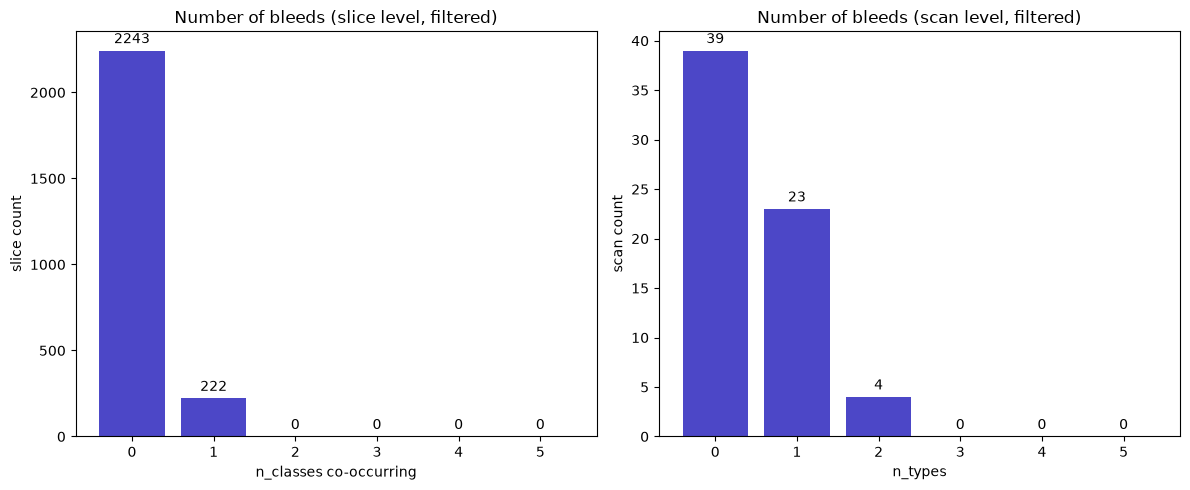

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

slice_x = list(range(6))
slice_y = [slice_n_classes_dist_after.get(n, 0) for n in slice_x]
bars0 = axes[0].bar(slice_x, slice_y, color='#4C47C7')
axes[0].set_title('Number of bleeds (slice level, filtered)')
axes[0].set_xlabel('n_classes co-occurring')
axes[0].set_ylabel('slice count')
axes[0].bar_label(bars0, padding=3)

scan_x = list(range(6))
scan_y = [scan_n_types_dist_after.get(n, 0) for n in scan_x]
bars1 = axes[1].bar(scan_x, scan_y, color='#4C47C7')
axes[1].set_title('Number of bleeds (scan level, filtered)')
axes[1].set_xlabel('n_types')
axes[1].set_ylabel('scan count')
axes[1].bar_label(bars1, padding=3)

plt.tight_layout()
plt.show()

#### Type of Bleed

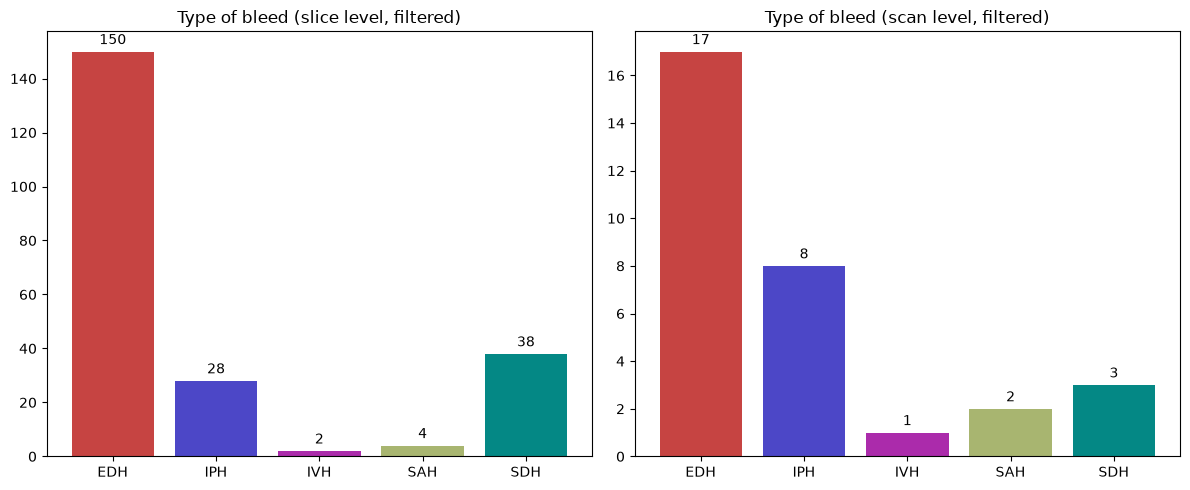

In [106]:
class_colors_short = {
    'EDH': (198, 68, 66), 'IPH': (76, 71, 199), 'IVH': (171, 43, 171),
    'SAH': (168, 181, 112), 'SDH': (4, 136, 133),
}
colors = [np.array(class_colors_short[t]) / 255 for t in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars0 = axes[0].bar(order, slice_type_counts_after.values, color=colors)
axes[0].set_title('Type of bleed (slice level, filtered)')
axes[0].bar_label(bars0, padding=3)

bars1 = axes[1].bar(order, scan_type_counts_after.values, color=colors)
axes[1].set_title('Type of bleed (scan level, filtered)')
axes[1].bar_label(bars1, padding=3)

plt.tight_layout()
plt.show() 

#### Volume of Bleed

In [107]:
labelsTs_dir = TEST2_DIR / "labelsTs"

lesion_sizes_mm3 = {c: [] for c in range(1, 6)}

for pnum in selected_patients:
    cid = f"ctich_{pnum:03d}"
    label_path = labelsTs_dir / f"{cid}.nii"
    if not label_path.exists():
        continue

    img = nib.load(str(ct_map[pnum]))
    mask = np.asarray(nib.load(str(label_path)).dataobj)
    spacing = img.header.get_zooms()
    voxel_volume_mm3 = float(np.prod(spacing))

    for c in range(1, 6):
        class_mask = (mask == c)
        if not class_mask.any():
            continue
        labeled, n_components = ndimage.label(class_mask)
        sizes_vox = ndimage.sum(class_mask, labeled, index=range(1, n_components + 1))
        lesion_sizes_mm3[c].extend((sizes_vox * voxel_volume_mm3).tolist())

rows = []
for c in range(1, 6):
    sizes = np.array(lesion_sizes_mm3[c])
    rows.append({
        'class_id': c,
        'name': csv_to_short_id_name.get(c) if False else class_names[c],
        'n_lesions': len(sizes),
        'min_mm3': float(sizes.min()) if len(sizes) else np.nan,
        'median_mm3': float(np.median(sizes)) if len(sizes) else np.nan,
        'max_mm3': float(sizes.max()) if len(sizes) else np.nan,
        'mean_mm3': float(sizes.mean()) if len(sizes) else np.nan,
    })

df_lesion_size_filtered = pd.DataFrame(rows)
display(df_lesion_size_filtered)

,class_id,name,n_lesions,min_mm3,median_mm3,max_mm3,mean_mm3
0,1,EDH,25,0.76,4751.00,74063.11,8837.38
1,2,IPH,11,71.69,492.11,5842.29,1338.72
2,3,IVH,1,745.56,745.56,745.56,745.56
3,4,SAH,2,1694.90,1734.16,1773.41,1734.16
4,5,SDH,12,0.85,1.53,40937.16,5908.46
